# ¿Sirve este dataset para entrenar los modelos de precio?

Limpieza de los datos corruptos y diagnóstico mediante clustering, **por separado para venta y para
arriendo**, que son los dos modelos que vamos a construir.

## El enfoque

Vamos a construir **dos modelos independientes**:

| Modelo | Datos que usa | Objetivo |
|---|---|---|
| **Venta** | Todos los avisos de venta (casas y departamentos) | Estimar el precio de venta en UF |
| **Arriendo** | Todos los avisos de arriendo (casas y departamentos) | Estimar el arriendo mensual en CLP |

Van separados porque los objetivos tienen **escalas incomparables** —miles de UF contra cientos de
miles de pesos— y porque ninguna propiedad está simultáneamente en venta y en arriendo. Juntarlos
haría que cualquier análisis recuperara trivialmente esa división sin decirnos nada útil.

El diagnóstico se aplica **igual a los dos conjuntos**, para poder compararlos.

### La idea del diagnóstico

> **Agrupamos las propiedades usando solo sus atributos, sin dejar que el algoritmo vea el precio.
> Después miramos si los grupos resultantes tienen precios distintos.**

Si al agrupar por superficie, dormitorios y ubicación resulta que unos grupos valen mucho más que
otros, entonces los atributos contienen información sobre el precio y un modelo supervisado puede
aprovecharla. Si todos los grupos tienen el mismo precio mediano, los atributos no discriminan y el
dataset no sirve para lo que queremos.

Es una prueba **no paramétrica**: no asume ninguna forma funcional. No dice cuál será el error del
modelo final —un modelo supervisado siempre lo hará mejor que agrupar a ciegas— sino que establece
una **cota inferior de la señal disponible**.

⚠️ El precio queda **fuera** de la matriz de clustering. Incluirlo haría la prueba circular: los
grupos tendrían precios distintos por construcción y no habríamos aprendido nada.

### Las variables que vamos a usar

| Variable | Qué es | Por qué debería importar |
|---|---|---|
| `m2_util` | Superficie interior habitable, en m² | Es el determinante principal del precio en cualquier mercado |
| `m2_total` | Útil más terrazas; en casas suele ser el terreno | Distingue una propiedad con exterior de una sin él |
| `dormitorios` | Número de dormitorios (0 = monoambiente) | Define el tipo de hogar al que apunta |
| `banos` | Número de baños | Proxy del estándar de la propiedad |
| `estacionamientos` | Estacionamientos incluidos | En Santiago suma valor de forma independiente |
| `bodegas` | Bodegas incluidas | Lo mismo, con menor peso |
| `antiguedad` | Años desde la construcción (2026 − año) | Un edificio nuevo se transa distinto que uno de 1970 |
| `gastos_comunes_clp` | Gasto común mensual | Proxy del nivel del edificio: conserjería, amenidades |
| `es_casa` | 1 si es casa, 0 si es departamento | Cada conjunto mezcla ambos tipos, y se comportan distinto |
| `lat`, `lon` | Coordenadas | La ubicación es el otro gran determinante junto con la superficie |

**Fuera de la matriz, a propósito:** `precio_uf` y `precio_clp` porque son el objetivo;
`antiguedad_aviso_dias` y `fecha_publicacion` porque cuánto lleva publicado un aviso es
*consecuencia* del precio y no causa; e `id_aviso`, `url`, `titulo` y `descripcion` por ser
identificadores y texto libre.

### Qué esperamos obtener

1. **¿Los datos tienen estructura?** Con el estadístico de Hopkins, y con un control que verifica
   que lo que mide no sea un artefacto.
2. **¿Cuántas dimensiones reales hay?** Con PCA, para ver si los atributos aportan información
   independiente o son en el fondo dos o tres cosas repetidas.
3. **¿Cuántos grupos naturales existen?** Con el coeficiente de silueta.
4. **¿Los grupos tienen precios distintos?** Es la pregunta que decide todo. Con **η²** (eta
   cuadrado): qué proporción de la varianza del precio explica la pertenencia al grupo.
5. **¿El clustering redescubre la geografía?** Si agrupando por atributos aparecen las comunas
   solas, la ubicación tiene señal real y no es una variable decorativa.
6. **¿Hay zonas mal representadas?** Los grupos con pocas observaciones son la región donde el
   modelo tendrá que extrapolar, y donde se equivocará más.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

SEMILLA = 42
ANIO = 2026
DB = Path("data/ofertas_unificado.sqlite")
COLORES = ["#0A6B67", "#8A3E5C", "#C08A2E", "#3B6EA5", "#6B7A3E"]
print(f"pandas {pd.__version__} · numpy {np.__version__}")

pandas 3.0.5 · numpy 2.5.2


## Paso 0 — Carga

La base se abre en **modo solo lectura**: el notebook nunca escribe en `data/`. Toda la limpieza
ocurre en memoria.

Dos convenciones del dataset que hay que deshacer: los faltantes son el **texto `"SIN_DATO"`** y no
`NULL`, y todas las columnas están tipadas **`TEXT`** aunque contengan números. El orden importa:
primero el centinela a `NaN`, después el casteo. Al revés no se distingue un faltante legítimo de un
valor que no parsea.

In [2]:
with sqlite3.connect(f"file:{DB.as_posix()}?mode=ro", uri=True, timeout=15) as con:
    crudo = pd.read_sql_query("SELECT * FROM ofertas", con)

df = crudo.replace("SIN_DATO", pd.NA)
NUMERICAS = ["precio_uf", "precio_clp", "m2_util", "m2_total", "dormitorios", "banos",
             "estacionamientos", "bodegas", "ano_construccion", "antiguedad_anos",
             "gastos_comunes_clp", "lat", "lon"]
for c in NUMERICAS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.drop(columns=["publica"])   # 100% vacia en las 15.808 filas

print(f"{len(df):,} avisos x {df.shape[1]} columnas")
print(pd.crosstab(df["operacion"], df["tipo"], margins=True, margins_name="total"))

15,808 avisos x 29 columnas
tipo       casa  departamento  total
operacion                           
arriendo    224          5611   5835
venta      3124          6849   9973
total      3348         12460  15808


## Paso 1 — Limpieza de los datos corruptos

Estos problemas se detectaron en una primera pasada de clustering: k-means los aisló en grupos
propios porque están tan lejos de todo lo demás que forman su propio conglomerado. El clustering
funcionó como **detector automático de anomalías**.

Hay dos tipos de arreglo, y la distinción importa:

**Reparaciones** — el dato existe pero está mal puesto, y se recupera:

- **`ano_construccion` y `antiguedad_anos` intercambiados.** En 166 avisos el año quedó en el campo
  de la antigüedad y viceversa: `ano_construccion = 4` con `antiguedad_anos = 2022`. Se detectan
  porque uno cae en rango de antigüedad y el otro en rango de año, y se intercambian.
- **Precios sin convertir.** El 27/07 falló la conversión de moneda y quedaron avisos con solo uno
  de los dos precios. Se reconstruye el que falta con la UF deducida de los propios datos, en
  **ambas direcciones**.

**Anulaciones** — el valor es imposible, se pone a `NaN` pero **la fila se conserva** porque el
resto del aviso es válido:

- `estacionamientos` o `bodegas` > 10 → es el conteo del **edificio entero**, no de la unidad.
  Hay estudios de 29 m² con 540 estacionamientos.
- `dormitorios` > 10, `gastos_comunes` > 3 millones/mes, `ano_construccion` fuera de 1900–2030.
- `lat`/`lon` fuera de la caja que contiene las cuatro comunas.
- `m2_total` < `m2_util` → se anula el total, que es el campo secundario.
- `gastos_comunes = 0` **solo en departamentos**: ahí significa «no informado». En casas el cero es
  real y se conserva.

In [3]:
RANGOS = {"estacionamientos": (0, 10), "bodegas": (0, 10), "dormitorios": (0, 10),
          "banos": (1, 12), "ano_construccion": (1900, 2030),
          "gastos_comunes_clp": (0, 3_000_000)}
BBOX_LAT, BBOX_LON = (-33.62, -33.40), (-70.72, -70.48)

limpio = df.copy()
registro = []


def anotar(nombre, n, tipo):
    registro.append({"arreglo": nombre, "filas": int(n), "tipo": tipo})


# --- REPARACION 1: los dos campos de antiguedad estan intercambiados ---------
swap = (limpio["ano_construccion"].between(0, 60)
        & limpio["antiguedad_anos"].between(1900, 2030))
limpio.loc[swap, ["ano_construccion", "antiguedad_anos"]] = \
    limpio.loc[swap, ["antiguedad_anos", "ano_construccion"]].to_numpy()
anotar("ano_construccion <-> antiguedad_anos intercambiados", swap.sum(), "reparado")

# --- REPARACION 2: precios sin convertir, en ambas direcciones ---------------
ambos = limpio["precio_clp"].notna() & limpio["precio_uf"].notna() & (limpio["precio_uf"] > 0)
UF = float((limpio.loc[ambos, "precio_clp"] / limpio.loc[ambos, "precio_uf"]).median())

falta_uf = limpio["precio_uf"].isna() & limpio["precio_clp"].notna()
limpio.loc[falta_uf, "precio_uf"] = limpio.loc[falta_uf, "precio_clp"] / UF
anotar("precio_uf reconstruido desde CLP", falta_uf.sum(), "reparado")

falta_clp = limpio["precio_clp"].isna() & limpio["precio_uf"].notna()
limpio.loc[falta_clp, "precio_clp"] = limpio.loc[falta_clp, "precio_uf"] * UF
anotar("precio_clp reconstruido desde UF", falta_clp.sum(), "reparado")

# --- ANULACIONES: valores imposibles, la fila se conserva --------------------
for col, (lo, hi) in RANGOS.items():
    fuera = limpio[col].notna() & ~limpio[col].between(lo, hi)
    limpio.loc[fuera, col] = np.nan
    anotar(f"{col} fuera de [{lo:,}, {hi:,}]", fuera.sum(), "anulado")

geo_mala = limpio["lat"].notna() & ~(limpio["lat"].between(*BBOX_LAT)
                                     & limpio["lon"].between(*BBOX_LON))
limpio.loc[geo_mala, ["lat", "lon"]] = np.nan
anotar("lat/lon fuera de las 4 comunas", geo_mala.sum(), "anulado")

incoherente = limpio["m2_total"].notna() & (limpio["m2_util"] > limpio["m2_total"])
limpio.loc[incoherente, "m2_total"] = np.nan
anotar("m2_total menor que m2_util", incoherente.sum(), "anulado")

gc_ambiguo = (limpio["tipo"] == "departamento") & (limpio["gastos_comunes_clp"] == 0)
limpio.loc[gc_ambiguo, "gastos_comunes_clp"] = np.nan
anotar("gastos_comunes = 0 en departamento (no informado)", gc_ambiguo.sum(), "anulado")

# --- Derivadas ---------------------------------------------------------------
limpio["antiguedad"] = ANIO - limpio["ano_construccion"]
limpio["es_casa"] = (limpio["tipo"] == "casa").astype(float)

print(f"UF deducida de los datos: {UF:,.2f} CLP\n")
reporte = pd.DataFrame(registro)
reporte["% del total"] = (100 * reporte["filas"] / len(limpio)).round(2)
print(reporte.to_string(index=False))
print(f"\nNo se elimino ninguna fila: siguen las {len(limpio):,} originales.")

UF deducida de los datos: 40,844.79 CLP

                                            arreglo  filas     tipo  % del total
ano_construccion <-> antiguedad_anos intercambiados    185 reparado         1.17
                   precio_uf reconstruido desde CLP   3102 reparado        19.62
                   precio_clp reconstruido desde UF   3747 reparado        23.70
                  estacionamientos fuera de [0, 10]    134  anulado         0.85
                           bodegas fuera de [0, 10]    116  anulado         0.73
                       dormitorios fuera de [0, 10]     16  anulado         0.10
                             banos fuera de [1, 12]     32  anulado         0.20
           ano_construccion fuera de [1,900, 2,030]     18  anulado         0.11
         gastos_comunes_clp fuera de [0, 3,000,000]      3  anulado         0.02
                     lat/lon fuera de las 4 comunas      5  anulado         0.03
                         m2_total menor que m2_util    410  anulado 

## Paso 2 — Los dos conjuntos de entrenamiento

Ahora sí se separan, y cada uno recibe el filtro de rango que corresponde a su escala. Este es el
único paso que **descarta filas**: un precio o una superficie fuera de rango no se puede reparar.

In [4]:
FILTROS = {
    "venta":    {"target": "precio_uf",  "precio": (500, 60_000),        "m2": (20, 800)},
    "arriendo": {"target": "precio_clp", "precio": (150_000, 4_000_000), "m2": (15, 600)},
}

conjuntos = {}
for op, f in FILTROS.items():
    sub = limpio[limpio["operacion"] == op]
    antes = len(sub)
    sub = sub[sub[f["target"]].between(*f["precio"]) & sub["m2_util"].between(*f["m2"])]
    conjuntos[op] = sub.reset_index(drop=True)
    print(f"{op.upper():<9} {antes:>6,} avisos -> {len(sub):>6,}  "
          f"(descarta {antes-len(sub):>3}, {100*(antes-len(sub))/antes:.1f}%)   "
          f"objetivo: {f['target']}")

print()
for op, sub in conjuntos.items():
    print(f"{op:<9} composicion: {sub['tipo'].value_counts().to_dict()}")

VENTA      9,973 avisos ->  9,812  (descarta 161, 1.6%)   objetivo: precio_uf
ARRIENDO   5,835 avisos ->  5,662  (descarta 173, 3.0%)   objetivo: precio_clp

venta     composicion: {'departamento': 6730, 'casa': 3082}
arriendo  composicion: {'departamento': 5462, 'casa': 200}


## Paso 3 — Herramientas del diagnóstico

Las mismas funciones se aplican a los dos conjuntos, para que la comparación sea justa.

In [5]:
ATRIBUTOS = ["m2_util", "m2_total", "dormitorios", "banos", "estacionamientos",
             "bodegas", "antiguedad", "gastos_comunes_clp", "es_casa", "lat", "lon"]

assert not {"precio_uf", "precio_clp"} & set(ATRIBUTOS), "el precio no puede entrar"


def preparar(sub, operacion):
    """Matriz de atributos escalada (sin precio) y el objetivo por separado."""
    X = StandardScaler().fit_transform(
        SimpleImputer(strategy="median").fit_transform(sub[ATRIBUTOS]))
    y = sub[FILTROS[operacion]["target"]].to_numpy(float)
    return X, y, np.log(y)


def hopkins(X, fraccion=0.05, semilla=0):
    """0,5 = ruido uniforme; cercano a 1 = muy agrupado."""
    rng = np.random.default_rng(semilla)
    n, d = X.shape
    m = max(int(fraccion * n), 50)
    idx = rng.choice(n, m, replace=False)
    w = NearestNeighbors(n_neighbors=2).fit(X).kneighbors(X[idx])[0][:, 1]
    art = rng.uniform(X.min(axis=0), X.max(axis=0), size=(m, d))
    u = NearestNeighbors(n_neighbors=1).fit(X).kneighbors(art)[0].ravel()
    return u.sum() / (u.sum() + w.sum())


def eta_cuadrado(y, grupos):
    """Proporcion de la varianza de y que explica la pertenencia al grupo."""
    y, grupos = np.asarray(y, float), np.asarray(grupos)
    ss_total = ((y - y.mean()) ** 2).sum()
    ss_entre = sum(((y[grupos == g].mean() - y.mean()) ** 2) * (grupos == g).sum()
                   for g in np.unique(grupos))
    return ss_entre / ss_total


datos = {}
for op, sub in conjuntos.items():
    X, y, ly = preparar(sub, op)
    datos[op] = {"X": X, "y": y, "log_y": ly, "df": sub}
    print(f"{op:<9} matriz {X.shape[0]:>6,} x {X.shape[1]}   "
          f"objetivo mediano: {np.median(y):>12,.0f}")

print("\n% de valores imputados por variable:")
imput = pd.DataFrame({op: (c[ATRIBUTOS].isna().mean() * 100).round(1)
                      for op, c in conjuntos.items()})
print(imput.to_string())

venta     matriz  9,812 x 11   objetivo mediano:        3,902
arriendo  matriz  5,662 x 11   objetivo mediano:      480,000

% de valores imputados por variable:
                    venta  arriendo
m2_util               0.0       0.0
m2_total              4.6      26.9
dormitorios          28.6      20.5
banos                12.2       5.5
estacionamientos     44.1      55.2
bodegas              16.7      26.2
antiguedad           10.6      43.4
gastos_comunes_clp   29.3      32.3
es_casa               0.0       0.0
lat                   0.6      24.0
lon                   0.6      24.0


## Procedimiento 1 — ¿Tienen estructura los datos?

El **estadístico de Hopkins** compara la distancia entre puntos reales y sus vecinos, contra esa
misma distancia para puntos artificiales repartidos al azar en el mismo espacio.

- **H ≈ 0,5** → indistinguible del ruido uniforme: no hay grupos que encontrar.
- **H > 0,75** → hay agrupamiento claro.

Hopkins es sensible a la dimensionalidad y a las distribuciones sesgadas, así que se acompaña de un
**control**: los mismos datos con cada columna barajada por separado. Eso destruye toda relación
entre variables pero conserva sus distribuciones marginales. Si el valor real no supera al control,
Hopkins no está midiendo estructura sino la forma de las distribuciones.

In [6]:
print(f"{'conjunto':<12}{'Hopkins':>10}{'control':>10}{'diferencia':>13}   veredicto")
print("-" * 74)
for op, d in datos.items():
    real = np.mean([hopkins(d["X"], semilla=s) for s in range(10)])
    rng = np.random.default_rng(SEMILLA)
    Xb = np.column_stack([rng.permutation(col) for col in d["X"].T])
    ctrl = np.mean([hopkins(Xb, semilla=s) for s in range(10)])
    veredicto = "informativo" if real - ctrl > 0.05 else "NO informativo"
    print(f"{op:<12}{real:>10.3f}{ctrl:>10.3f}{real-ctrl:>13.3f}   {veredicto}")

print("\nUna diferencia cercana a cero significa que Hopkins da lo mismo con datos reales")
print("que con datos donde se destruyo toda relacion entre variables: en ese caso el")
print("estadistico refleja lo asimetrico de las distribuciones, no estructura real.")

conjunto       Hopkins   control   diferencia   veredicto
--------------------------------------------------------------------------


venta            0.979     0.958        0.020   NO informativo


arriendo         0.985     0.973        0.012   NO informativo

Una diferencia cercana a cero significa que Hopkins da lo mismo con datos reales
que con datos donde se destruyo toda relacion entre variables: en ese caso el
estadistico refleja lo asimetrico de las distribuciones, no estructura real.


## Procedimiento 2 — ¿Cuántas dimensiones reales tiene el problema?

PCA responde si los once atributos aportan información independiente o si son en el fondo dos o tres
cosas repetidas. Mucha redundancia no invalida el dataset, pero anticipa qué variables pesarán.

In [7]:
for op, d in datos.items():
    pca = PCA().fit(d["X"])
    acum = pca.explained_variance_ratio_.cumsum()
    n80 = int((acum < 0.80).sum()) + 1
    print(f"\n=== {op.upper()} ===")
    print(f"varianza por componente: "
          f"{[f'{100*v:.0f}%' for v in pca.explained_variance_ratio_[:6]]}")
    print(f"componentes para el 80% de la varianza: {n80} de {d['X'].shape[1]}")
    cargas = pd.DataFrame(pca.components_[:3].T, index=ATRIBUTOS,
                          columns=["PC1", "PC2", "PC3"]).round(2)
    print(cargas.to_string())


=== VENTA ===
varianza por componente: ['35%', '12%', '11%', '9%', '7%', '6%']
componentes para el 80% de la varianza: 6 de 11
                     PC1   PC2   PC3
m2_util             0.40  0.19  0.06
m2_total            0.06 -0.05 -0.08
dormitorios         0.37 -0.10 -0.31
banos               0.33  0.23 -0.39
estacionamientos    0.34  0.11  0.08
bodegas             0.28  0.28 -0.09
antiguedad          0.31  0.07  0.50
gastos_comunes_clp -0.22  0.50 -0.43
es_casa             0.44 -0.15  0.18
lat                -0.06  0.70  0.27
lon                 0.21 -0.20 -0.43

=== ARRIENDO ===
varianza por componente: ['28%', '14%', '11%', '10%', '9%', '7%']
componentes para el 80% de la varianza: 7 de 11
                     PC1   PC2   PC3
m2_util             0.50  0.01  0.05
m2_total            0.06 -0.06  0.04
dormitorios         0.41  0.16 -0.19
banos               0.37  0.24 -0.37
estacionamientos    0.27  0.05 -0.03
bodegas             0.22  0.32  0.21
antiguedad          0.34 -0.18  0.46


## Procedimiento 3 — ¿Cuántos grupos naturales hay?

El **coeficiente de silueta** mide, para cada propiedad, si se parece más a las de su grupo que a las
del grupo vecino. Va de −1 a 1: sobre 0,5 la estructura es fuerte, bajo 0,25 los grupos se solapan.

La **inercia** siempre baja al añadir grupos, así que no sirve como criterio absoluto: se busca el
codo, el punto donde añadir un grupo más deja de compensar.

venta     siluetas: ['0.365', '0.208', '0.324', '0.233', '0.234', '0.198', '0.202', '0.201', '0.207']
          mejor k = 2 (silueta 0.365), rango 0.198-0.365


arriendo  siluetas: ['0.638', '0.221', '0.218', '0.221', '0.230', '0.238', '0.223', '0.256', '0.241']
          mejor k = 2 (silueta 0.638), rango 0.218-0.638


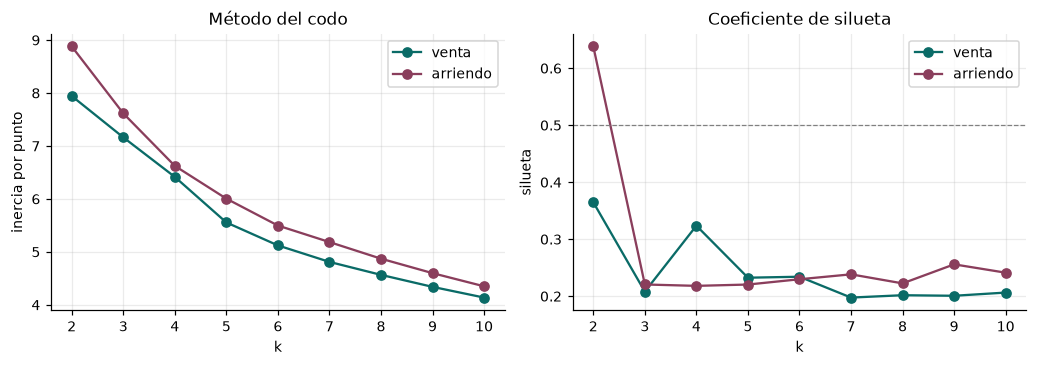

In [8]:
ks = list(range(2, 11))
fig, ejes = plt.subplots(1, 2, figsize=(9.5, 3.4))

for (op, d), color in zip(datos.items(), COLORES):
    X = d["X"]
    muestra = np.random.default_rng(SEMILLA).choice(len(X), min(3000, len(X)), replace=False)
    inercias, siluetas = [], []
    for k in ks:
        km_k = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(X)
        inercias.append(km_k.inertia_ / len(X))
        siluetas.append(silhouette_score(X[muestra], km_k.labels_[muestra]))
    d["siluetas"] = siluetas
    ejes[0].plot(ks, inercias, "o-", color=color, label=op)
    ejes[1].plot(ks, siluetas, "o-", color=color, label=op)
    print(f"{op:<9} siluetas: {[f'{s:.3f}' for s in siluetas]}")
    print(f"{'':<9} mejor k = {ks[int(np.argmax(siluetas))]} "
          f"(silueta {max(siluetas):.3f}), rango {min(siluetas):.3f}-{max(siluetas):.3f}")

ejes[0].set_xlabel("k"); ejes[0].set_ylabel("inercia por punto")
ejes[0].set_title("Método del codo"); ejes[0].legend()
ejes[1].set_xlabel("k"); ejes[1].set_ylabel("silueta")
ejes[1].set_title("Coeficiente de silueta"); ejes[1].legend()
ejes[1].axhline(0.5, ls="--", lw=0.8, color="gray")
plt.tight_layout(); plt.show()

## Procedimiento 4 — Perfil de los grupos

Fijamos **k = 5** en ambos conjuntos, un número manejable para interpretar. El precio aparece aquí
solo como columna descriptiva: no participó en formar los grupos.

In [9]:
K = 5
for op, d in datos.items():
    km = KMeans(n_clusters=K, n_init=20, random_state=SEMILLA).fit(d["X"])
    d["km"], d["labels"] = km, km.labels_
    sub = d["df"].assign(cluster=km.labels_)
    d["df"] = sub

    target = FILTROS[op]["target"]
    perfil = sub.groupby("cluster").agg(
        n=(target, "size"), casas_pct=("es_casa", lambda s: round(100 * s.mean())),
        m2=("m2_util", "median"), dorm=("dormitorios", "median"),
        banos=("banos", "median"), estac=("estacionamientos", "median"),
        antig=("antiguedad", "median"), precio=(target, "median"))
    perfil["precio_m2"] = (perfil["precio"] / perfil["m2"]).round(1)
    perfil["%"] = (100 * perfil["n"] / len(sub)).round(1)
    print(f"\n=== {op.upper()} — objetivo: {target} ===")
    print(perfil.round(1).to_string())


=== VENTA — objetivo: precio_uf ===
            n  casas_pct     m2  dorm  banos  estac  antig  precio  precio_m2     %
cluster                                                                            
0        1663         99  114.0   4.0    2.0    2.0   25.0  5615.0       49.3  16.9
1           2        100  107.5   4.0    2.5    2.0   10.0  8315.0       77.3   0.0
2        4039          2   60.0   2.0    2.0    1.0    8.0  3855.0       64.2  41.2
3        1352         99  160.0   4.0    2.0    2.0   60.0  9793.2       61.2  13.8
4        2756          0   47.0   2.0    1.0    0.0    7.0  2815.5       59.9  28.1

=== ARRIENDO — objetivo: precio_clp ===
            n  casas_pct     m2  dorm  banos  estac  antig     precio  precio_m2     %
cluster                                                                               
0        1563          0   56.0   2.0    2.0    1.0    4.0   520000.0     9285.7  27.6
1           1          0   45.0   3.0    1.0    0.0    0.0   285914.0    

## Procedimiento 5 — La prueba clave: ¿los grupos tienen precios distintos?

Aquí se decide si cada dataset sirve. **η² (eta cuadrado)** es la proporción de la varianza del
log-precio que explica la simple pertenencia a un grupo formado sin mirar el precio.

Referencia de Cohen: 0,01 efecto pequeño · 0,06 mediano · **0,14 grande**.

Se usa el logaritmo porque la distribución del precio es asimétrica a la derecha y unas pocas
propiedades caras dominarían la varianza en escala original.

In [10]:
print(f"{'conjunto':<12}{'eta²':>8}{'al azar':>10}{'veces':>8}   interpretacion")
print("-" * 70)
for op, d in datos.items():
    eta = eta_cuadrado(d["log_y"], d["labels"])
    rng = np.random.default_rng(SEMILLA)
    azar = np.mean([eta_cuadrado(d["log_y"], rng.permutation(d["labels"]))
                    for _ in range(200)])
    d["eta"] = eta
    nivel = "grande" if eta > 0.14 else "mediano" if eta > 0.06 else "pequeno"
    print(f"{op:<12}{eta:>8.3f}{azar:>10.4f}{eta/azar:>8,.0f}   efecto {nivel}")

for op, d in datos.items():
    target = FILTROS[op]["target"]
    r = d["df"].groupby("cluster")[target].describe(percentiles=[.25, .5, .75])
    print(f"\n=== {op.upper()} — {target} por grupo ===")
    print(r[["count", "25%", "50%", "75%"]].round(0).to_string())
    print(f"razon entre el grupo mas caro y el mas barato: "
          f"{r['50%'].max()/r['50%'].min():.2f}x")

conjunto        eta²   al azar   veces   interpretacion
----------------------------------------------------------------------


venta          0.435    0.0004   1,020   efecto grande
arriendo       0.489    0.0007     723   efecto grande

=== VENTA — precio_uf por grupo ===
          count     25%     50%      75%
cluster                                 
0        1663.0  3885.0  5615.0   7900.0
1           2.0  6982.0  8315.0   9648.0
2        4039.0  3100.0  3855.0   5285.0
3        1352.0  6700.0  9793.0  13125.0
4        2756.0  2205.0  2816.0   3500.0
razon entre el grupo mas caro y el mas barato: 3.48x

=== ARRIENDO — precio_clp por grupo ===
          count       25%        50%        75%
cluster                                        
0        1563.0  470000.0   520000.0   599000.0
1           1.0  285914.0   285914.0   285914.0
2        2755.0  345000.0   390000.0   450000.0
3         196.0  850000.0  1250000.0  1812500.0
4        1147.0  520000.0   600000.0   730000.0
razon entre el grupo mas caro y el mas barato: 4.37x


In [11]:
# Traduccion del diagnostico a la metrica que usaremos en el modelo: si predijeramos
# el precio con la sola mediana de cada grupo, cuanto nos equivocariamos.
print(f"{'conjunto':<12}{'MdAPE global':>14}{'MdAPE por grupo':>18}{'mejora':>10}")
print("-" * 56)
for op, d in datos.items():
    target = FILTROS[op]["target"]
    y = d["y"]
    pred = d["df"].groupby("cluster")[target].transform("median").to_numpy()
    m_grupo = np.median(100 * np.abs(pred - y) / y)
    m_global = np.median(100 * np.abs(np.median(y) - y) / y)
    print(f"{op:<12}{m_global:>13.1f}%{m_grupo:>17.1f}%{m_global-m_grupo:>9.1f} pts")

print("\nEs un piso, no una prediccion. Un modelo supervisado usa los atributos en")
print("detalle en vez de reducirlos a 5 categorias, y ademas esto esta medido en")
print("muestra, asi que es optimista. Sirve para saber que HAY senal, no cuanta.")

conjunto      MdAPE global   MdAPE por grupo    mejora
--------------------------------------------------------
venta                36.0%             27.2%      8.8 pts
arriendo             20.0%             13.3%      6.7 pts

Es un piso, no una prediccion. Un modelo supervisado usa los atributos en
detalle en vez de reducirlos a 5 categorias, y ademas esto esta medido en
muestra, asi que es optimista. Sirve para saber que HAY senal, no cuanta.


## Procedimiento 6 — ¿El clustering redescubre la geografía?

Si al agrupar por atributos las comunas aparecen separadas por sí solas, la ubicación tiene señal
propia y no es una variable decorativa. Es el argumento para incluir `lat` y `lon` en el modelo.

In [12]:
for op, d in datos.items():
    sub = d["df"]
    comp = pd.crosstab(sub["cluster"], sub["comuna"], normalize="index").mul(100).round(1)
    eta_com = eta_cuadrado(d["log_y"], sub["comuna"].to_numpy())
    print(f"\n=== {op.upper()} — composicion de cada grupo por comuna (%) ===")
    print(comp.to_string())
    print(f"comuna dominante en cada grupo: {comp.max(axis=1).round(0).to_dict()}")
    print(f"   (sin senal geografica, cada grupo tendria ~25% de cada comuna)")
    print(f"eta² de la comuna sola sobre el log-precio : {eta_com:.3f}")
    print(f"eta² de los {K} grupos de atributos         : {d['eta']:.3f}")


=== VENTA — composicion de cada grupo por comuna (%) ===
comuna   la-florida  macul  nunoa  san-miguel
cluster                                      
0              87.2    9.4    2.4         1.0
1             100.0    0.0    0.0         0.0
2              21.6   18.4   35.3        24.7
3               3.1   16.0   59.8        21.1
4              33.1   17.0   18.4        31.5
comuna dominante en cada grupo: {0: 87.0, 1: 100.0, 2: 35.0, 3: 60.0, 4: 33.0}
   (sin senal geografica, cada grupo tendria ~25% de cada comuna)
eta² de la comuna sola sobre el log-precio : 0.209
eta² de los 5 grupos de atributos         : 0.435

=== ARRIENDO — composicion de cada grupo por comuna (%) ===
comuna   la-florida  macul  nunoa  san-miguel
cluster                                      
0              41.4   20.9   16.2        21.6
1               0.0    0.0    0.0       100.0
2              29.1   17.9   28.3        24.7
3              49.5    8.2   36.2         6.1
4               2.1   16.2   65.2    

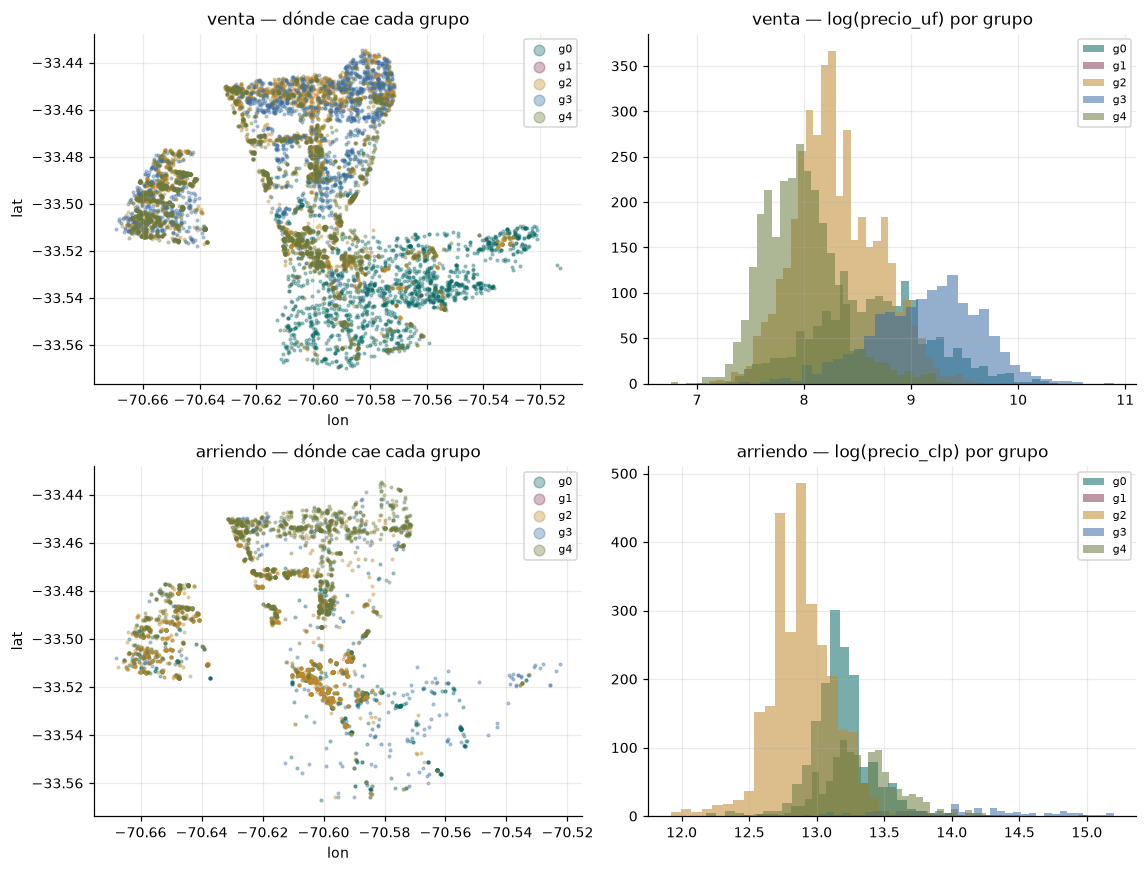

In [13]:
fig, ejes = plt.subplots(2, 2, figsize=(10.5, 8))
for fila, (op, d) in enumerate(datos.items()):
    sub, target = d["df"], FILTROS[op]["target"]
    for c in range(K):
        m = sub["cluster"] == c
        ejes[fila, 0].scatter(sub.loc[m, "lon"], sub.loc[m, "lat"], s=3, alpha=0.35,
                              color=COLORES[c], label=f"g{c}")
        ejes[fila, 1].hist(np.log(sub.loc[m, target]), bins=40, alpha=0.55,
                           color=COLORES[c], label=f"g{c}")
    ejes[fila, 0].set_title(f"{op} — dónde cae cada grupo")
    ejes[fila, 0].set_xlabel("lon"); ejes[fila, 0].set_ylabel("lat")
    ejes[fila, 0].legend(markerscale=4, fontsize=7)
    ejes[fila, 1].set_title(f"{op} — log({target}) por grupo")
    ejes[fila, 1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## Procedimiento 7 — ¿Hay zonas del espacio mal representadas?

Donde hay pocas observaciones el modelo tendrá que extrapolar, y ahí es donde fallará. Se mide con
el tamaño de cada grupo y con la distancia de cada propiedad a su centroide.

In [14]:
for op, d in datos.items():
    sub, km, X = d["df"], d["km"], d["X"]
    dist = np.linalg.norm(X - km.cluster_centers_[km.labels_], axis=1)
    tam = sub["cluster"].value_counts().sort_index()
    print(f"\n=== {op.upper()} ===")
    print(f"tamano de los grupos: {tam.to_dict()}")
    print(f"el mas pequeno concentra el {100*tam.min()/len(sub):.1f}% de los avisos")
    print(f"propiedades mas alla del percentil 99 de distancia al centroide: "
          f"{int((dist > np.percentile(dist, 99)).sum())}")
    cols = ["comuna", "tipo", "m2_util", "m2_total", "dormitorios", "banos",
            "estacionamientos", "antiguedad", FILTROS[op]["target"]]
    print("las 5 mas extremas:")
    print(sub.assign(d=dist).nlargest(5, "d")[cols].to_string(index=False))


=== VENTA ===
tamano de los grupos: {0: 1663, 1: 2, 2: 4039, 3: 1352, 4: 2756}
el mas pequeno concentra el 0.0% de los avisos
propiedades mas alla del percentil 99 de distancia al centroide: 99
las 5 mas extremas:
    comuna         tipo  m2_util  m2_total  dormitorios  banos  estacionamientos  antiguedad   precio_uf
     nunoa departamento     76.0      88.0          NaN    2.0               NaN         6.0  7500.00000
la-florida departamento     77.0      84.0          3.0    2.0               NaN        17.0  3758.12925
la-florida         casa    560.0   20000.0         10.0    6.0              10.0         NaN 20000.00000
     macul departamento     41.0      43.0          2.0    1.0               NaN         0.0  4090.00000
la-florida departamento     57.0      61.0          2.0    2.0               NaN         7.0  4500.00000

=== ARRIENDO ===
tamano de los grupos: {0: 1563, 1: 1, 2: 2755, 3: 196, 4: 1147}
el mas pequeno concentra el 0.0% de los avisos
propiedades mas alla del p

## Procedimiento 8 — ¿De dónde vienen los faltantes? (crítico para arriendo)

En el Paso 3 apareció algo que no cuadra: **arriendo tiene 24 % de coordenadas imputadas y 43 % de
antigüedad imputada**, contra 0,6 % y 10,6 % en venta. Esa diferencia no es aleatoria y conviene
saber de dónde viene, porque el modelo de arriendo es el que más la va a sufrir.

In [15]:
for op, d in datos.items():
    sub = d["df"]
    cob = sub.groupby("sitio")[ATRIBUTOS].apply(
        lambda g: (g.notna().mean() * 100).round(1), include_groups=False)
    print(f"\n=== {op.upper()} — cobertura (% con dato) por fuente ===")
    print(f"filas por fuente: {sub['sitio'].value_counts().to_dict()}")
    print(cob.T.to_string())

print("\n" + "=" * 70)
print("pi = portalinmobiliario   ·   cp = chilepropiedades")
print("=" * 70)
arr = datos["arriendo"]["df"]
cp = arr[arr["sitio"] == "cp"]
vacias = [c for c in ATRIBUTOS if cp[c].notna().sum() == 0]
print(f"\nchilepropiedades aporta {len(cp):,} avisos de arriendo "
      f"({100*len(cp)/len(arr):.1f}% del conjunto)")
print(f"y no trae NINGUN dato en: {vacias}")
print(f"\nEsas {len(cp):,} filas reciben la mediana en {len(vacias)} de los {len(ATRIBUTOS)} "
      f"atributos.\nNo son faltantes al azar: es una fuente entera sin esos campos.")


=== VENTA — cobertura (% con dato) por fuente ===
filas por fuente: {'pi': 9812}
sitio                  pi
m2_util             100.0
m2_total             95.4
dormitorios          71.4
banos                87.8
estacionamientos     55.9
bodegas              83.3
antiguedad           89.4
gastos_comunes_clp   70.7
es_casa             100.0
lat                  99.4
lon                  99.4

=== ARRIENDO — cobertura (% con dato) por fuente ===
filas por fuente: {'pi': 4359, 'cp': 1303}
sitio                  cp     pi
m2_util             100.0  100.0
m2_total              0.0   95.0
dormitorios          98.8   73.8
banos                99.5   93.0
estacionamientos     50.3   43.2
bodegas               0.0   95.9
antiguedad            0.0   73.5
gastos_comunes_clp    0.0   87.9
es_casa             100.0  100.0
lat                   0.0   98.8
lon                   0.0   98.8

pi = portalinmobiliario   ·   cp = chilepropiedades

chilepropiedades aporta 1,303 avisos de arriendo (23.0% del

## Conclusión

**Los dos datasets sirven, y con señal fuerte.** Pero no son igual de buenos, y el de arriendo tiene
un problema estructural que conviene resolver antes de modelar.

### 1. La señal existe en ambos, y es grande

| | η² | vs. azar | MdAPE global | MdAPE por grupo | Ganancia |
|---|---|---|---|---|---|
| **Venta** | **0,435** | 1.020× | 36,0 % | 27,2 % | 8,8 pts |
| **Arriendo** | **0,489** | 723× | 20,0 % | 13,3 % | 6,7 pts |

Cinco grupos formados *sin ver el precio* explican el 43,5 % de la varianza del log-precio en venta
y el 48,9 % en arriendo. La referencia de Cohen considera **0,14 un efecto grande**, así que ambos
están tres veces por encima. Agrupando al azar se obtiene 0,0004–0,0007.

**Ambos datasets pasan la prueba.** Los atributos que tenemos contienen información real sobre el
precio, y un modelo supervisado puede aprovecharla.

### 2. El arriendo es más predecible que la venta

Esto no lo esperaba, y es un resultado útil. El arriendo tiene **η² más alto** (0,489 vs 0,435) y
una **dispersión de partida mucho menor**: predecir con la mediana global ya da 20 % de error en
arriendo contra 36 % en venta.

Tiene sentido de mercado: los arriendos son más estandarizados. Un departamento de 2 dormitorios en
Ñuñoa se arrienda dentro de un rango estrecho, mientras que su precio de venta depende del estado
interior, la terminación y la negociación, cosas que no están en el dataset.

**Implicación práctica:** conviene esperar mejores métricas del modelo de arriendo que del de venta,
y no interpretar esa diferencia como que uno está mejor construido que el otro.

### 3. No hay segmentos discretos: hay un continuo

La silueta se queda entre **0,20 y 0,37** en venta y entre **0,22 y 0,64** en arriendo, pero en
ambos casos cae a ~0,22 en cuanto *k* pasa de 2. No existen grupos naturales bien separados.

Parece mala noticia y no lo es: **para una regresión es el escenario deseable**. Significa que los
atributos varían de forma continua y el precio los sigue de forma continua. Un η² alto con silueta
baja es la firma de una **superficie de precios suave**. Si hubiera segmentos discretos habría que
plantearse un modelo por segmento; no los hay, así que un modelo continuo sobre cada conjunto es lo
correcto.

*(El 0,64 de arriendo en k = 2 no contradice esto: separa 193 propiedades grandes y caras —mediana
120 m² y 1,2 millones— del resto. Es un solo grupo pequeño muy alejado, no una partición del
mercado.)*

### 4. Hopkins no sirvió en ninguno de los dos, y el control lo demuestra

| | Hopkins | Control (columnas barajadas) | Diferencia |
|---|---|---|---|
| Venta | 0,979 | 0,958 | **0,020** |
| Arriendo | 0,985 | 0,973 | **0,012** |

Un H de 0,98 sugeriría agrupamiento extremo. Pero al barajar cada columna por separado —destruyendo
toda relación entre variables y conservando solo sus distribuciones marginales— el estadístico da
prácticamente lo mismo.

Hopkins está detectando lo **asimétrico de las distribuciones**, no estructura real. Es una
limitación conocida del estadístico con datos sesgados. **Sin el control habríamos reportado
«H = 0,98, estructura clarísima» en ambos, y habría sido falso.**

### 5. La ubicación tiene señal propia en ambos

En venta, el grupo 0 es **87 % La Florida** y el grupo 3 es **60 % Ñuñoa**, sin que la comuna entrara
en la matriz: el clustering redescubrió la geografía solo con `lat` y `lon`. En arriendo, el grupo 4
es **65 % Ñuñoa**.

La comuna por sí sola explica un η² de **0,209** en venta y **0,181** en arriendo. Confirma que la
ubicación debe entrar al modelo y que las coordenadas crudas bastan para capturarla.

### 6. ⚠️ El problema del modelo de arriendo: una fuente entera sin datos

**ChilePropiedades aporta 1.303 avisos, el 23 % del conjunto de arriendo, y no trae ningún dato en
6 de los 11 atributos:** `m2_total`, `bodegas`, `antiguedad`, `gastos_comunes_clp`, `lat` y `lon`.

No son faltantes al azar. Es una fuente completa que carece de esos campos, y esas 1.303 filas
reciben la mediana en más de la mitad de sus atributos. En la práctica el modelo de arriendo se
entrena sobre **dos poblaciones distintas**:

- **portalinmobiliario** (4.359 avisos): datos completos, con geo y antigüedad.
- **chilepropiedades** (1.303 avisos): solo comuna, tipo, superficie útil, dormitorios y baños.

En venta esto no ocurre: las 9.812 filas vienen todas de portalinmobiliario.

**Qué hacer:** añadir una variable indicadora de qué campos venían informados —el propio hecho de
que falten es información— y medir el error por fuente al validar. Si el error en las filas de
chilepropiedades es mucho mayor, hay que decidir si se las excluye o se marcan como de baja
confianza en el producto.

### 7. La limpieza recuperó datos en vez de descartarlos

| Arreglo | Filas | Tipo |
|---|---|---|
| `ano_construccion` ↔ `antiguedad_anos` intercambiados | 185 | reparado |
| `precio_uf` reconstruido desde CLP | 3.102 | reparado |
| `precio_clp` reconstruido desde UF | 3.747 | reparado |
| `m2_total` menor que `m2_util` | 410 | anulado |
| `gastos_comunes = 0` en departamento | 775 | anulado |
| `estacionamientos` / `bodegas` > 10 (conteo del edificio) | 250 | anulado |
| Resto de rangos imposibles y geo fuera de Santiago | 74 | anulado |

**No se eliminó ninguna fila en la limpieza:** siguen las 15.808. Solo el filtro final de rango de
precio y superficie descarta avisos, y son pocos (1,6 % en venta, 3,0 % en arriendo).

El hallazgo más rentable fue el de los campos intercambiados: la primera pasada detectó 203
`ano_construccion` inválidos, pero al descubrir que el año estaba en el campo de la antigüedad,
**185 se recuperaron enteros** y solo quedaron 18 realmente irrecuperables.

### Qué hacer ahora

1. **Ambos modelos son viables.** Proceder con venta y arriendo por separado, como estaba planeado.
2. **Un modelo continuo por conjunto**, no uno por cluster: la silueta baja dice que no hay
   segmentos reales que justifiquen partir.
3. **Añadir indicadores de faltante** como variables, sobre todo en arriendo, donde la ausencia
   identifica la fuente.
4. **Medir el error por fuente** al validar el modelo de arriendo, y decidir qué hacer con
   chilepropiedades a la luz de ese número.
5. **Quedan outliers residuales.** Los grupos degenerados (n = 2 en venta, n = 1 en arriendo)
   señalan casos aún extremos: una casa con 20.000 m² de terreno, departamentos de 562 m². Vale la
   pena un recorte por percentil de precio/m² dentro de cada comuna antes de entrenar.